# Non-Circular Gears and Conjugate Pitch Curves

Non-circular gears are designed to realize a prescribed, non-constant transmission ratio.
At the pitch level, two planar curves roll without slip around fixed centers separated by distance $L$.
If the first pitch radius is $r_1(\theta)$, the second must satisfy
$$
r_2(\theta)=L-r_1(\theta), \qquad
\frac{d\phi}{d\theta}=\frac{r_1(\theta)}{L-r_1(\theta)},
$$
where $\phi(\theta)$ is the accumulated rotation of gear 2 relative to gear 1.

This notebook focuses on **geometrically correct pitch-curve meshing**:
for each contact direction $\theta$, both curves touch at one point with a common tangent and no interpenetration.


We use the closure condition
$$
\int_0^{2\pi} \frac{r_1(\theta)}{L-r_1(\theta)}\,d\theta = 2\pi
$$
to determine $L$ by bisection.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, Dropdown

plt.rcParams["figure.dpi"] = 120


In [2]:
def solve_center_distance(theta, r1):
    dtheta = theta[1] - theta[0]
    rmax = np.max(r1)
    L_lo, L_hi = rmax * 1.001, rmax * 8.0

    def F(L):
        return np.sum(r1 / (L - r1)) * dtheta - 2 * np.pi

    for _ in range(80):
        L_mid = 0.5 * (L_lo + L_hi)
        if F(L_mid) > 0:
            L_lo = L_mid
        else:
            L_hi = L_mid
    return 0.5 * (L_lo + L_hi)


def angle_map(theta, r1, L):
    dtheta = theta[1] - theta[0]
    dphi = r1 / (L - r1) * dtheta
    phi = np.concatenate([[0.0], np.cumsum(dphi)])
    return phi[:-1]  # same length as theta


def contact_pair(theta0, r1_fun, L):
    r1 = r1_fun(theta0)
    p1 = np.array([r1 * np.cos(theta0), r1 * np.sin(theta0)])
    p2 = np.array([L - (L - r1) * np.cos(theta0), -(L - r1) * np.sin(theta0)])
    pc = 0.5 * (p1 + p2)
    return p1, p2, pc


We define a few driver pitch profiles $r_1(\theta)$ and compute conjugate profiles
$r_2(\theta)=L-r_1(\theta)$.


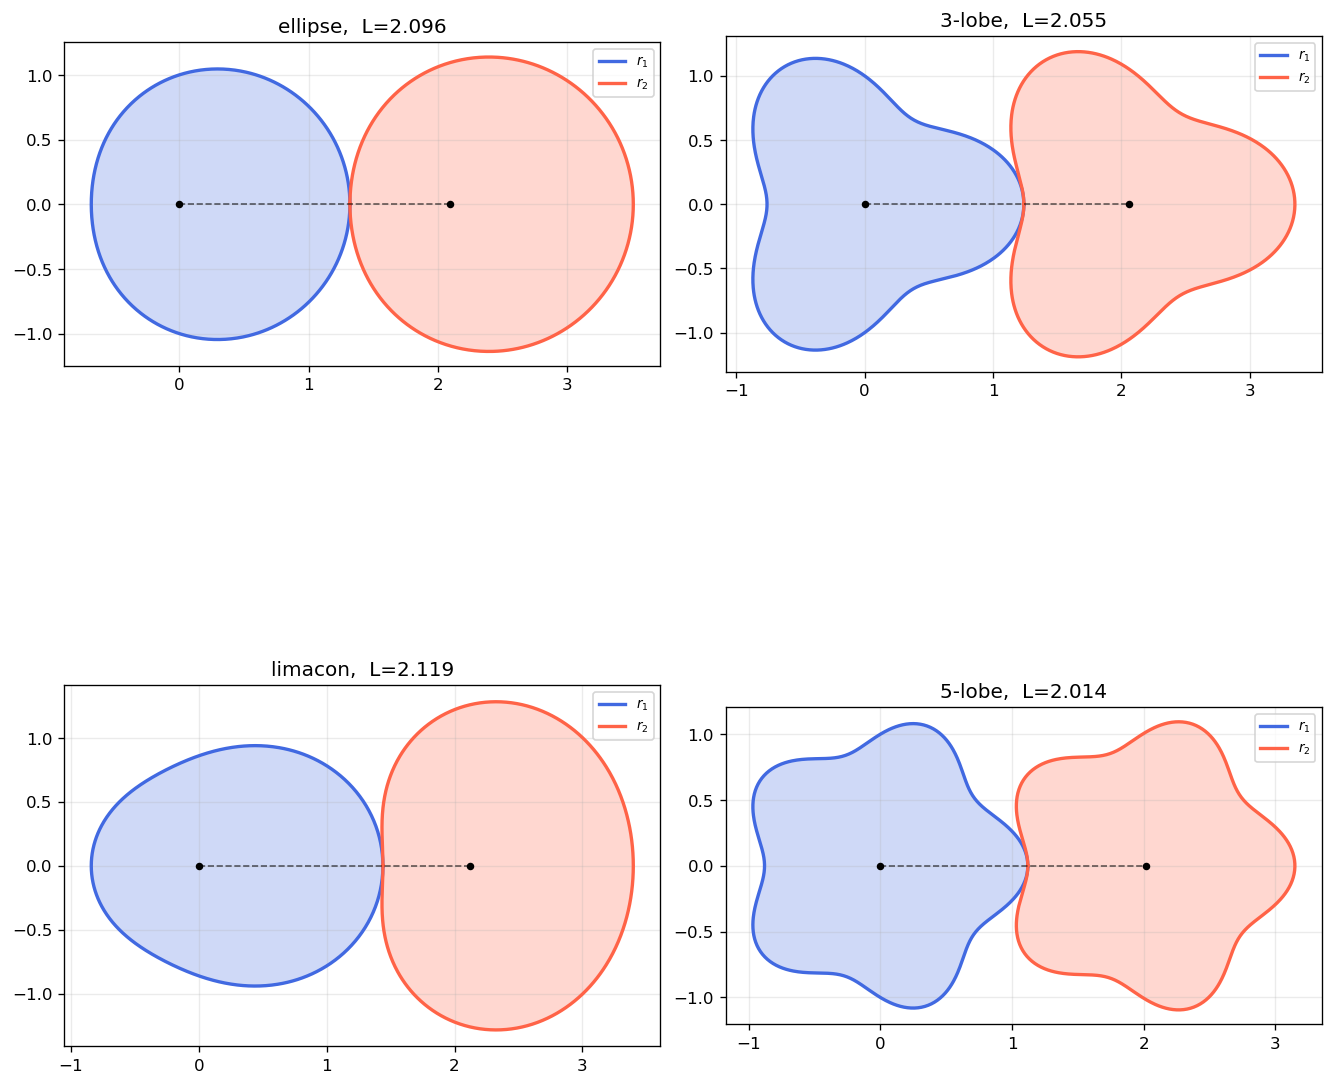

In [3]:
n = 800
theta = np.linspace(0, 2 * np.pi, n, endpoint=False)

def r_ellipse(t): return 1.0 + 0.32 * np.cos(t)
def r_trilobe(t): return 1.0 + 0.24 * np.cos(3 * t)
def r_limacon(t): return 1.0 + 0.30 * np.cos(t) + 0.14 * np.cos(2 * t)
def r_fivelobe(t): return 1.0 + 0.12 * np.cos(5 * t)

profiles = {
    "ellipse": r_ellipse,
    "3-lobe": r_trilobe,
    "limacon": r_limacon,
    "5-lobe": r_fivelobe,
}

fig, axes = plt.subplots(2, 2, figsize=(11, 11), constrained_layout=True)
for ax, (name, rfun) in zip(axes.ravel(), profiles.items()):
    r1 = rfun(theta)
    L = solve_center_distance(theta, r1)
    r2 = L - r1

    x1, y1 = r1 * np.cos(theta), r1 * np.sin(theta)
    x2 = L - r2 * np.cos(theta)
    y2 = -r2 * np.sin(theta)

    ax.fill(x1, y1, alpha=0.25, color="royalblue")
    ax.plot(x1, y1, color="royalblue", lw=2, label="$r_1$")
    ax.fill(x2, y2, alpha=0.25, color="tomato")
    ax.plot(x2, y2, color="tomato", lw=2, label="$r_2$")
    ax.plot([0, L], [0, 0], "k--", lw=1, alpha=0.6)
    ax.plot([0, L], [0, 0], "k.", ms=7)
    ax.set_title(f"{name},  L={L:.3f}")
    ax.set_aspect("equal")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
plt.show()


The instantaneous speed ratio is
$$
\frac{\omega_2}{\omega_1}=\frac{r_1(\theta)}{L-r_1(\theta)}.
$$


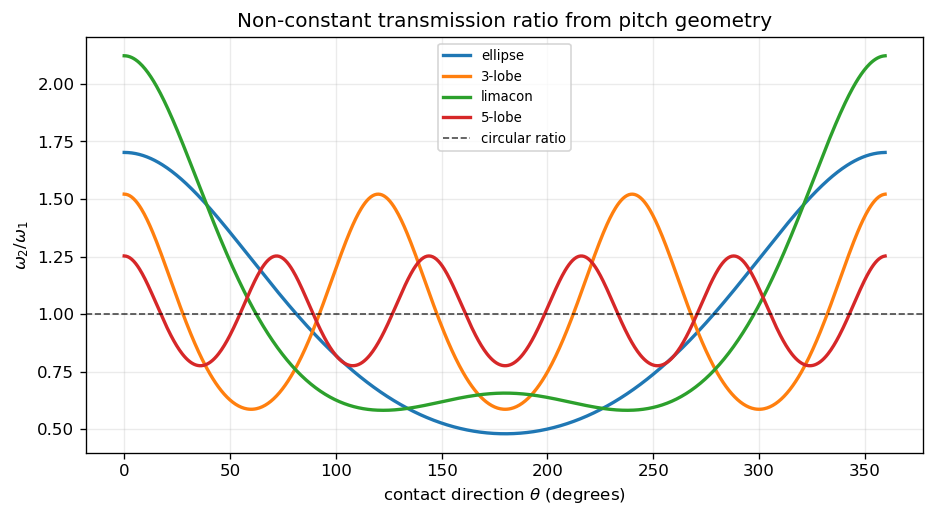

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for name, rfun in profiles.items():
    r1 = rfun(theta)
    L = solve_center_distance(theta, r1)
    ratio = r1 / (L - r1)
    ax.plot(np.degrees(theta), ratio, lw=2, label=name)
ax.axhline(1.0, color="k", ls="--", lw=1, alpha=0.7, label="circular ratio")
ax.set_xlabel(r"contact direction $\theta$ (degrees)")
ax.set_ylabel(r"$\omega_2/\omega_1$")
ax.set_title("Non-constant transmission ratio from pitch geometry")
ax.grid(alpha=0.25)
ax.legend(fontsize=8)
plt.show()


For each angle $\theta_0$, we display the two contact points
$$
p_1(\theta_0)=r_1(\theta_0)\,e(\theta_0), \qquad
p_2(\theta_0)=\big(L,0\big)-(L-r_1(\theta_0))\,e(\theta_0),
$$
and their midpoint $p_c$ (which is the contact location in the pitch construction).


## Bibliographical Resources

- F. L. Litvin and A. Fuentes, *Gear Geometry and Applied Theory*, Cambridge University Press, 2nd ed., 2004.
- M. C. Smith, “Synthesis of Noncircular Gears for Function Generation,” *Journal of Mechanical Design*, 2003.
- B. H. Tongue, *Principles of Vibration*, Oxford University Press, transmission sections with variable-ratio mechanisms.
